# **Nivell 1 - Visualització analítica guiada en Python**

In [159]:
import os
import socket
import sys

print("Equip:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("USERNAME") or os.getenv("USER"))

Equip: DESKTOP-LJTKAJ4
Python: C:\Program Files\Python314\python.exe
Usuari: POL


In [160]:
%pip install sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [161]:
import sqlalchemy

In [162]:
user = "root"
password = "Cibernarium73*"
host = "localhost"
database = "star_model"

engine = sqlalchemy.create_engine(
    f"mysql+pymysql://{user}:{password}@{host}/{database}")

In [163]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

## **Exercici 1:** Preguntes analítiques directes (sense integracions complexes)
🌍 Context: Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.
Aspectes a revisar i analitzar:

» Identificar quina informació és necessària. Quin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

Preguntes analítiques: (només utilitzant la taula de transaccions) :

### 1.Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

Selecciona la columna temporal adequada.
Defineix el nivell
icona enllaç extern
temporal
d'anàlisi.

Compta el nombre de registres per període temporal.
Ordena els resultats cronològicament.
Visualitza l'evolució amb un gràfic de línies amb pandas.

Ejecutamos la consulta para ver todas las 'Tablas' y 'Tabla Vista' de la Base de Datos 'star_model'

In [164]:
df_taules = pd.read_sql("SHOW TABLES;", engine)
df_taules

,Tables_in_star_model
0,dim_companies
1,dim_credit_cards
2,dim_users
3,fact_transactions
4,vistamarketing


Definimos la consulta SQL para extraer los datos de la tabla

In [165]:
df = pd.read_sql('SELECT * FROM fact_transactions', con=engine)

Ejecutamos la consulta y cargamos los resultados al DataFrame

Visualizamos las primeras 5 filas

In [166]:
df.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.199929,1.435540,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.757296,-95.379637,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.548884,-113.503053,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.208370,5.690806,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.553486,-113.499134,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82


Visualizamos la estructura

In [167]:
df.shape

(99999, 19)

Visualizamos el nombre de las columnas

In [168]:
df.columns

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km'],
      dtype='str')

#### Seleccionamos la columna temporal adequada: Nos aseguramos de que df['timestamp'] es de tipo datetime.

In [169]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

#### Definimos el nivel temporal de análisis. Agrupar por año y contar el numero de transacciones

In [170]:
transacciones_por_año = df.groupby(df['timestamp'].dt.year).size()

#### Cuenta el numero de registros por periodo temporal. Ordena el resultado cronológicamente.

In [171]:
transacciones_por_año

timestamp
2015     9870
2016     9854
2017     9915
2018     9912
2019    10015
2020    10093
2021    10298
2022    10106
2023     9985
2024     9951
dtype: int64

EXPLICACIÓN:

>>* df['timestamp']: Acede a la columna 'timestamp' del DataFrame.

>>* .dt.year: seleccionamos unicamente el año de la fecha.

>>* df.groupby(...): Agrupa todas las filas de DataFrame segun el año que se ha extraido en el paso anterior.(GROUP BY de SQL).

>>* .size(): Cuenta el numero total de filas que hay dentro de cada grupo. Es decir el total de transacciones por año.(COUNT de SQL).

>>* transacciones_por_año = ...: Guarda esta información (una serie con el año como índice y el recuento de las transacciones como valor) dentro de la variable.

#### Visualiza la evolución con un gráfico de lineas con pandas

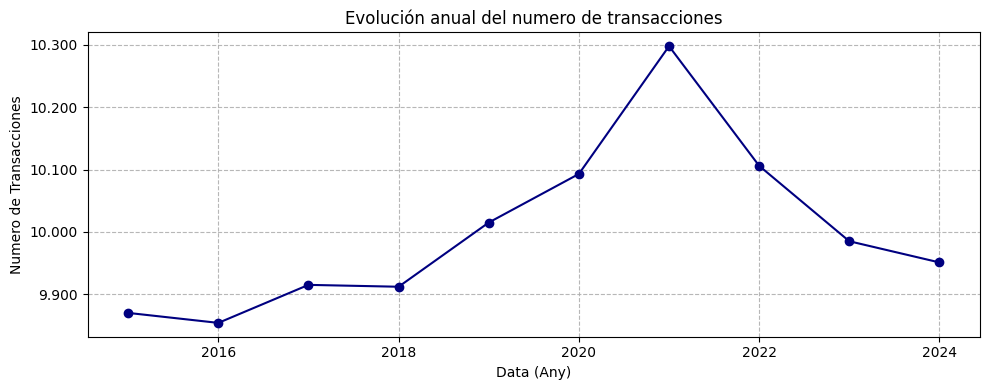

In [172]:
plt.figure(figsize=(10, 4))
transacciones_por_año.plot(kind='line', marker='o', color='navy')

plt.title('Evolución anual del numero de transacciones')
plt.xlabel('Data (Any)')
plt.ylabel('Numero de Transacciones')
plt.grid(True, linestyle='--', alpha=0.9)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.'))
)

plt.tight_layout()
plt.show()

**Descripción del gráfico:**
El gráfico muestra la evolución de transacciones entre 2015 y 2024. Tras una etapa inicial estable, se observa un crecimiento sostenido desde 2018 hasta alcanzar un pico máximo en 2021 (10.300 transacciones). Posteriormente, el volumen inicia un descenso progresivo hasta los niveles actuales. La pandemia figura como una de las posibles causas de este cambio en la evolución del gráfico.

### 2.Que usuarios generaron mas volumen de facturación. Ejemplo de pasos guiados con 'Seaborn'.

#### Identifica la columna que representa el usuario.

In [173]:
df['user_id']

0        4713
1        2118
2        2115
3        3025
4         215
         ... 
99994     429
99995    3074
99996    1008
99997     680
99998    1103
Name: user_id, Length: 99999, dtype: int64

#### Agrupa las transacciones por usuario y calcula el volumen total de facturación sumando la columna 'amount'. Ordena los usuarios de mayor a menor volumne de facturación.

In [174]:
top_users = (
    df.groupby('user_id')['amount']
    .sum()
    .reset_index()
    .sort_values(by='amount', ascending=False))

#### Selecciona los N. Por ejemplo, los 15 primeros usuarios.

In [175]:
top_15_users = top_users.head(15)

#### Representa el resultado mediante un grafico de barras utilitzando Seaborn.

##### Convertimos 'user_id' a string para que Seaborn lo identifique como categoria .

In [176]:
top_15_users['user_id'] = top_15_users['user_id'].astype(str)

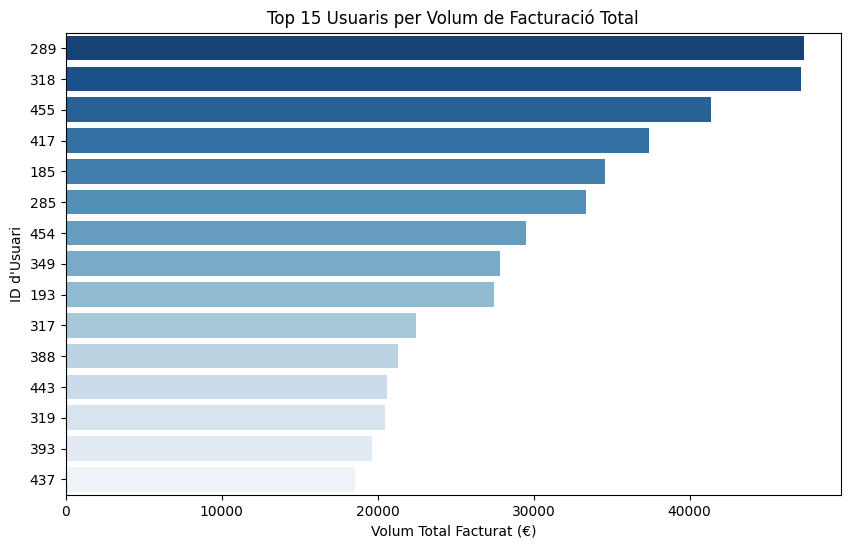

In [177]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_15_users,
    x='amount',
    y='user_id',
    order=top_15_users['user_id'],
    hue='user_id',
    palette='Blues_r',
    legend=False)


plt.title("Top 15 Usuaris per Volum de Facturació Total")
plt.xlabel("Volum Total Facturat (€)")
plt.ylabel("ID d'Usuari")



plt.show()

**Descripción del gráfico:**
El gráfico identifica los 15 principales usuarios según su volumen total facturado en euros. Muestra una distribución decreciente donde un grupo reducido encabeza el consumo total de la plataforma. Este gráfico ayuda a detectar a los clientes más valiosos (VIP) para orientar estrategias de fidelización.

### 3.Hay diferencias en la distribución del importe de las transacciones segun la hora del dia y si han estado aceptadas o rehusadas? Ejemplo de pasos guiados con 'Seaborn'.

#### Crea una nueva columna con la hora del dia a partir del df['timestamp'].

In [178]:
df['hour'] = df['timestamp'].dt.hour

In [179]:
df[['hour', 'timestamp']].head()

,hour,timestamp
0,7,2024-08-28 07:16:46
1,15,2020-07-14 15:37:45
2,19,2017-09-04 19:44:53
3,18,2017-01-05 18:19:25
4,4,2023-09-23 04:51:43


In [180]:
df['hour_AM_PM'] = df['timestamp'].dt.strftime('%I:00 %p')

In [181]:
df[['hour', 'timestamp', 'hour_AM_PM']].head()

,hour,timestamp,hour_AM_PM
0,7,2024-08-28 07:16:46,07:00 AM
1,15,2020-07-14 15:37:45,03:00 PM
2,19,2017-09-04 19:44:53,07:00 PM
3,18,2017-01-05 18:19:25,06:00 PM
4,4,2023-09-23 04:51:43,04:00 AM


#### Utiliza un violinplot de 'Seaborn' para analizar la distribución de los importes.

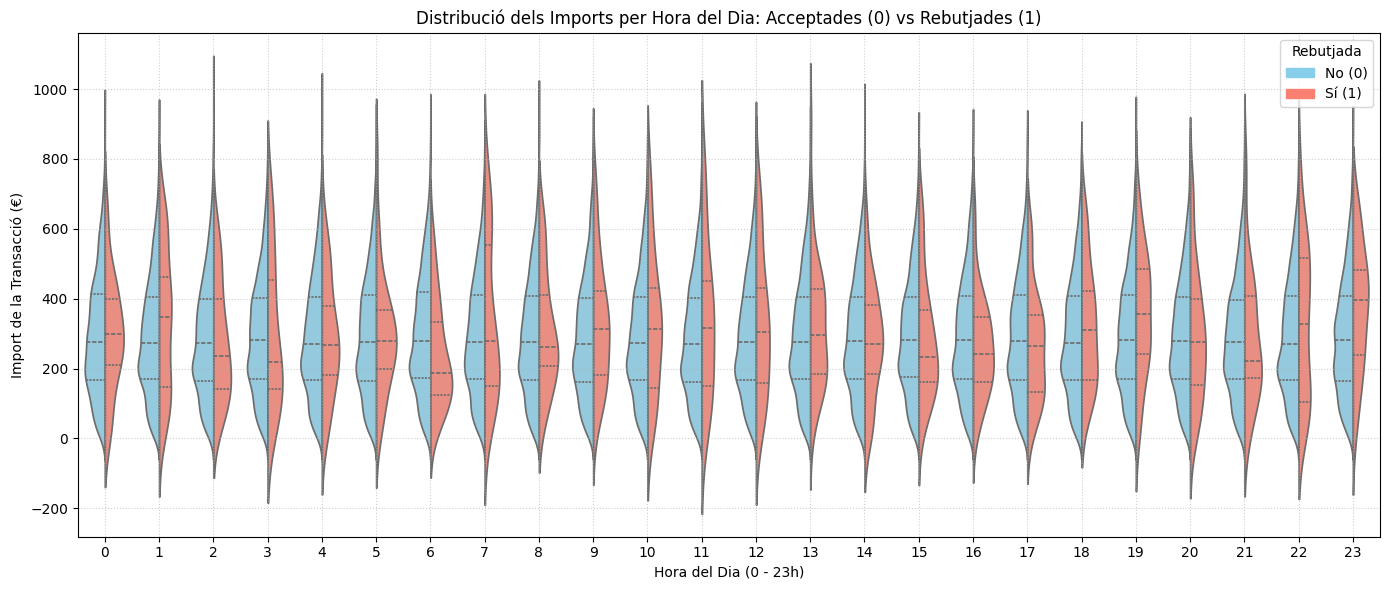

In [182]:
plt.figure(figsize=(14, 6))

ax = sns.violinplot(
    data=df,
    x='hour',
    y='amount',
    hue='declined',
    split=True,
    inner='quartile',
    palette={0: 'skyblue', 1: 'salmon'})

plt.title("Distribució dels Imports per Hora del Dia: Acceptades (0) vs Rebutjades (1)")
plt.xlabel("Hora del Dia (0 - 23h)")
plt.ylabel("Import de la Transacció (€)")
plt.grid(True, linestyle=':', alpha=0.6)

handles = [
    mpatches.Patch(color='skyblue', label='No (0)'),
    mpatches.Patch(color='salmon', label='Sí (1)')]

plt.legend(handles=handles, title="Rebutjada")

plt.tight_layout()
plt.show()

**Descripción del gráfico:** Este gráfico de violín compara la distribución del importe de la transacción y  operaciones aceptadas (azul) y rechazadas (rojo) a lo largo de las 24 horas del día. Muestra un comportamiento homogéneo durante todo la jornada, sin diferencias significativas en la mediana ni en los cuartiles entre ambos grupos, lo que indica que el importe no es un factor determinante para el rechazo de las operaciones.

Analisis horas con medianas

>>* Asigna: 'x' para la hora del dia, y 'hue' por el estado de la transacción.

>>* split = True para comparar 'aceptadas/rehusadas' y 'inner' con 'cuartiles' para mostrar mediana y cuartiles.

### 4.Quins dies de la setmana es concentra més activitat de venda?

👉 Per a cada pregunta:

#### Construeix una visualització senzilla en Python sense utilitzar IA.

In [183]:
dias_ordre = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',]

In [184]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_of_week'] = df['timestamp'].dt.day_name()

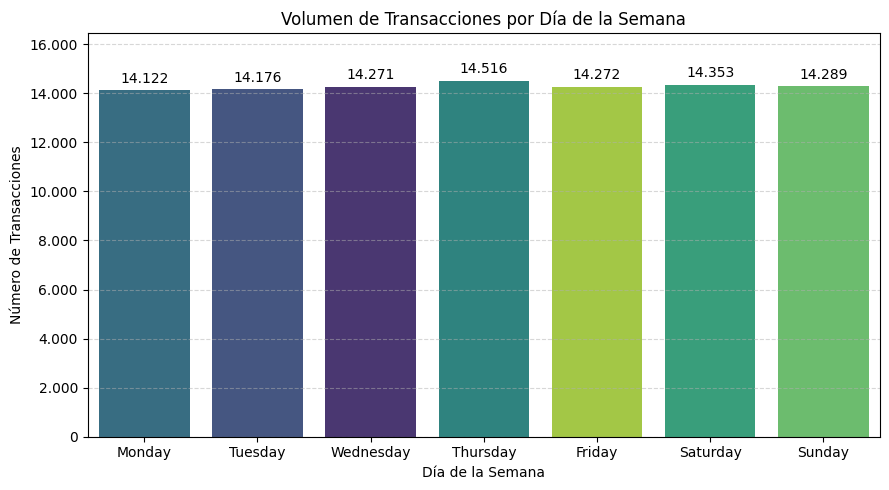

In [185]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df,
    x='day_of_week',
    order=dias_ordre,
    hue='day_of_week',
    palette='viridis',
    legend=False)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f'{int(x):,}'.replace(',', '.'),
        padding=3)

plt.title("Volumen de Transacciones por Día de la Semana")
plt.xlabel("Día de la Semana")
plt.ylabel("Número de Transacciones")

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

plt.ylim(0, ax.get_ylim()[1] * 1.08)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Descripción del gráfico:**
El gráfico representa la distribución del volumen total de transacciones registradas según cada día de la semana. Permite identificar la regularidad del comportamiento de los usuarios, destacando los días de mayor tráfico operativo frente a las jornadas de menor actividad. Esta información facilita la planificación estratégica de promociones puntuales y la optimización de recursos en la plataforma.

#### Interpretación.

>>* El volumen de transacciones es estable y se mantiene entre 14.000 y 14.500 transacciones todos los dias. No hay picos de bajada ni de subida significativos.

>>* El comportamiento de negocio 24/7. Este tipo de gráfico sugiere un modelo de comercio electrónico donde no hay diferencias claras entre dias laborables y/o dias festivos.

>>* Diferencia mínima entre el dia con más transacciones y el que tiene menos. No podemos asegurar que este gráfico nos indique un patrón continuado (hay una variación porcentual mínima).

#### Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.

In [186]:
dias_ordre = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',]

In [187]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

Creamos la tabla de frequencias  (Día Vs Hora)

In [188]:
pivot_dia_hora = pd.crosstab(df['day_of_week'], df['hour']).reindex(dias_ordre)

In [189]:
pivot_dia_hora

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,606,568,582,591,607,563,594,598,603,558,...,569,568,591,575,605,583,615,616,599,583
Tuesday,569,627,544,578,569,631,576,632,579,567,...,583,578,590,638,575,602,560,601,567,645
Wednesday,554,598,615,634,640,618,579,573,604,587,...,623,582,623,571,582,552,567,594,616,570
Thursday,590,611,567,591,621,608,608,597,627,631,...,596,594,593,622,636,566,571,638,611,571
Friday,582,578,600,594,588,630,661,559,605,591,...,590,615,586,589,586,622,566,611,552,607
Saturday,641,614,602,618,578,618,590,597,594,614,...,588,603,560,569,596,570,622,588,578,593
Sunday,583,625,577,604,590,605,561,559,600,603,...,651,634,607,571,588,539,572,617,591,565


Creación de un Mapa de Calor (Heatmap)

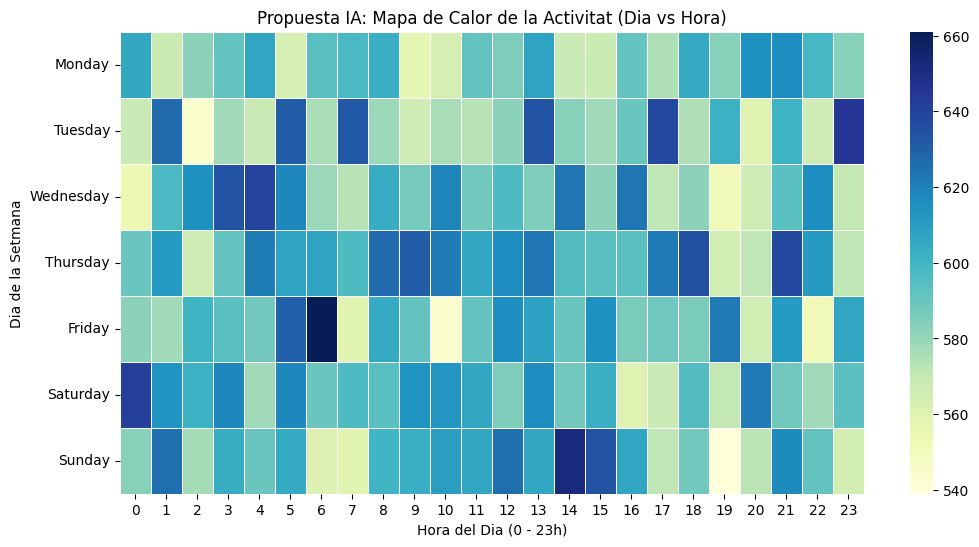

In [190]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_dia_hora, cmap='YlGnBu', linewidths=0.5, annot=False)

plt.title("Propuesta IA: Mapa de Calor de la Activitat (Dia vs Hora)")
plt.xlabel("Hora del Dia (0 - 23h)")
plt.ylabel("Dia de la Setmana")
plt.show()

**Descripción del gáfico:** Este mapa de calor muestra la intensidad de transacciones según el día de la semana y la hora. Los tonos oscuros indican picos de actividad, destacando momentos de alta concentración en días laborables (como el viernes por la mañana), mientras que los tonos claros marcan baja concentración. Esta distribución permite optimizar el mantenimiento del sistema y programar campañas comerciales específicas.

#### Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

Evaluación de la Propuesta de la IA:

>* Visualización Inicial (Countplot por día): Muestra qué día de la semana tiene mayor volumen global de ventas, pero pierde el detalle de cómo se distribuyen estas transacciones a lo largo de la jornada.

>* Propuesta Alternativa (Heatmap Día vs Hora): Aporta una segunda dimensión ($2D$). Permite identificar patrones operativos mucho más precisos por ejemplo, picos en franjas horarias concretas.

>* Conclusión: La propuesta alternativa (headmap) es superior para la toma de decisiones más especificas, puntuales y detalladas. Mientras que el gráfico inicial (countplot) resulta más adecuado para resúmenes ejecutivos y de logística.

## **Exercici 2:** Preguntes analítiques complexes (amb guia)
🌍 Context: Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.
Aquí sí que serà necessari:

> » Fer merge entre taules.

> » Utilitzar groupby, pivot_table, crosstab...

> » Aplicar agregacions, transformacions intermèdies i funcions.

Preguntes analítiques (amb guia general)

##> » Depenem excessivament d'un nombre reduït de països de companyies venedores?

Cargo la tabla fact_transactions

In [191]:
df_transactions = pd.read_sql('SELECT * FROM fact_transactions', engine)

Cargo la tabla dim_companies

In [192]:
df_companies = pd.read_sql('SELECT * FROM dim_companies', engine)

Comprobación: cargas de las 2 tablas

In [193]:
print(f"Files carregades a df_transactions: {len(df_transactions)}")
print(f"Files carregades a df_companies: {len(df_companies)}")

Files carregades a df_transactions: 99999
Files carregades a df_companies: 100


#### 1.Combinar la informació de transaccions amb la de companyies.

In [194]:
df_comp = df_transactions.merge(
    df_companies, left_on='business_id', right_on='company_id', how='inner')

In [195]:
print(f"Total de transaccions processades: {len(df_comp)}")
df_comp.head()

Total de transaccions processades: 99999


,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,decline_reason,distance_km,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.199929,1.435540,...,,59.95,b-2458,Eget Tincidunt Dui Institute,+18 210 327 5206,eget.laoreet@hotmail.org,Netherlands,https://www.eget-tincidunt-dui-institute.com,Toys,mid-market
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.757296,-95.379637,...,,1157.10,b-2390,Neque Tellus Imperdiet Corp.,+12 445 145 3593,vestibulum.ante.ipsum@aol.edu,Ireland,https://www.neque-tellus-imperdiet-corp.com,Food,budget
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.548884,-113.503053,...,,540.32,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.208370,5.690806,...,,28.52,b-2266,Mus Aenean Eget Foundation,+1 504 922 3000,mi.duis@hotmail.net,Sweden,https://www.mus-aenean-eget-foundation.com,Sports,mid-market
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.553486,-113.499134,...,,539.82,b-2598,Aliquam Iaculis Lacus Corp.,+23 674 242 3712,dictum@aol.org,Belgium,https://www.aliquam-iaculis-lacus-corp.com,Fashion,budget


#### 2-3-4.Agrupacions i calculs:
>>* Agrupar la facturació per país.

>>* Calcular la facturació total generada per cada país.

>>* Ordenar els països de major a menor facturació.
  

In [196]:
facturacion_pais = (
    df_comp.groupby('country')['amount']
    .sum()
    .reset_index()
    .sort_values(by='amount', ascending=False))

Renombramos las columnas ['País'] y ['Facturación Total (€)']

In [197]:
facturacion_pais.columns = ['País', 'Facturacion Total (€)']

In [198]:
facturacion_pais

,País,Facturacion Total (€)
12,Sweden,4928117.68
8,Netherlands,4506571.38
13,United Kingdom,4099117.08
7,Italy,4087557.38
5,Germany,4020364.07
4,France,1416084.26
14,United States,1101737.27
1,Belgium,952208.75
10,Norway,809288.82
6,Ireland,715220.46


#### >> 5.Calcular el percentatge acumulat sobre el total.

Calculamos la facturación total global

In [199]:
total_facturacion = facturacion_pais['Facturacion Total (€)'].sum()

In [200]:
facturacion_pais['Porcentaje%']= ((facturacion_pais['Facturacion Total (€)'] / total_facturacion) * 100).round(2)

In [201]:
facturacion_pais

,País,Facturacion Total (€),Porcentaje%
12,Sweden,4928117.68,16.82
8,Netherlands,4506571.38,15.38
13,United Kingdom,4099117.08,13.99
7,Italy,4087557.38,13.95
5,Germany,4020364.07,13.72
4,France,1416084.26,4.83
14,United States,1101737.27,3.76
1,Belgium,952208.75,3.25
10,Norway,809288.82,2.76
6,Ireland,715220.46,2.44


#### >> 6.Visualitzar.

Gráfico de barras

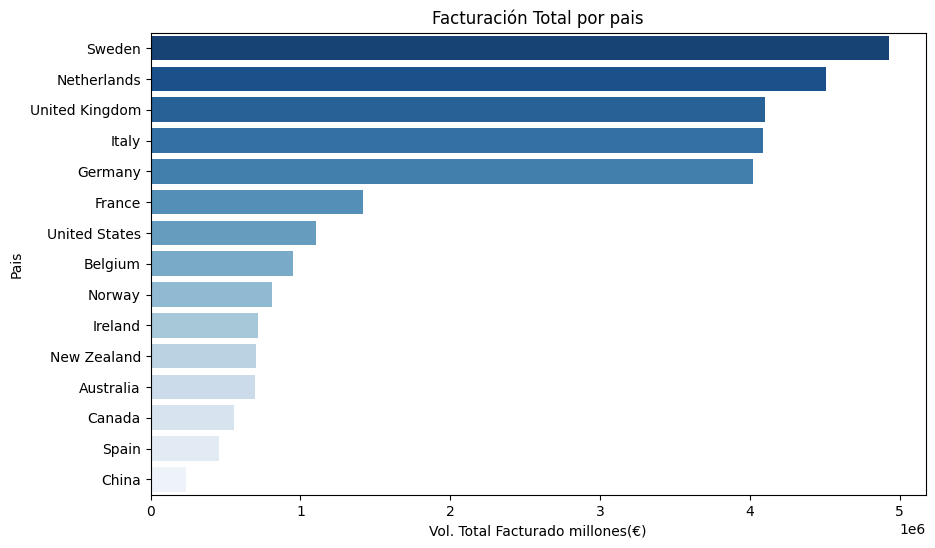

In [202]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=facturacion_pais,
    x='Facturacion Total (€)',
    y='País',
    order= facturacion_pais['País'],
    hue='País',
    palette='Blues_r',
    legend=False)

plt.title('Facturación Total por pais')
plt.xlabel('Vol. Total Facturado millones(€)')
plt.ylabel('Pais')
plt.show()

Volum total facturat en millons
Explicació del gràfic
Percentatge acumulat
Interpretar con datos tangibles

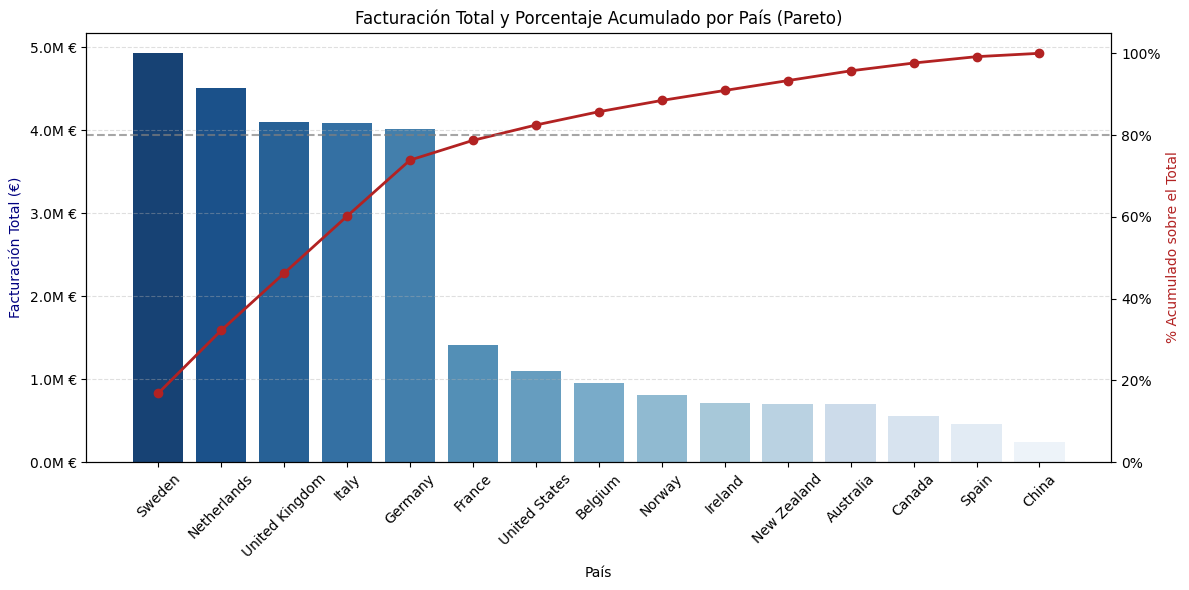

In [203]:
df_pareto = facturacion_pais.copy()
df_pareto['Porcentaje_Acumulado'] = df_pareto['Porcentaje%'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_pareto,
    x='País',
    y='Facturacion Total (€)',
    hue='País',
    palette='Blues_r',
    ax=ax1,
    legend=False)

ax1.set_title("Facturación Total y Porcentaje Acumulado por País (Pareto)")
ax1.set_xlabel("País")
ax1.set_ylabel("Facturación Total (€)", color='navy')
ax1.tick_params(axis='x', rotation=45)

ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M €'))

ax2 = ax1.twinx()
ax2.plot(
    df_pareto['País'],
    df_pareto['Porcentaje_Acumulado'],
    color='firebrick',
    marker='o',
    linewidth=2)

ax2.set_ylabel("% Acumulado sobre el Total", color='firebrick')
ax2.set_ylim(0, 105)

ax2.yaxis.set_major_formatter(ticker.PercentFormatter())

ax2.axhline(80, color='grey', linestyle='--', alpha=0.7)

ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Resultado del gráfico:**
* **Concentración del volumen:** Los primeros cinco países lideran claramente la facturación global, aportando individualmente entre 4,0M € y 4,9M € cada uno y distanciándose del resto de paises.
* **Cumplimiento del principio de Pareto:** La línea roja acumulada muestra que tan solo seis paises superan el umbral del 80% del negocio total, confirmando una elevada dependencia en un grupo reducido de países.
* **Desnivel pronunciado en la distribución:** Se aprecia una caída sustancial en la facturación a partir del sexto país, pasando de los 4,0M € del grupo dominante a valores inferiores a 1,5M € en los restantes.
* **Aportación 'mínima' de mercados secundarios:** Los últimos ocho países presentan valores muy reducidas con ingresos individuales por debajo de 1,0M €, contribuyendo únicamente al 20% restante del volumen global de facturación acumulada.
* **Estructura visual del gráfico:** El diagrama combina un eje principal de barras descendentes para los ingresos absolutos con un segundo eje de línea discontinua para rastrear el porcentaje acumulado.

## > » Existeix estacionalitat en les vendes?

#### 1.Treballar amb dates de transacció.

Formato datetime

In [204]:
df_comp['timestamp'] = pd.to_datetime(df_comp['timestamp'])

#### 2.Extreure la informació temporal rellevant (any i mes).

 Extraemos Año y Mes

In [205]:
df_comp['year'] = df_comp['timestamp'].dt.year
df_comp['month_num'] = df_comp['timestamp'].dt.month
df_comp['month_name'] = df_comp['timestamp'].dt.strftime('%b')  # Ex: Jan, Feb...

#### 3.**Calcular** el volum total de vendes (suma de amount) per any i mes.

Agrupar la suma de amount por año y mes

In [206]:
vendes_temps = (
    df_comp.groupby(['year', 'month_num', 'month_name'])['amount']
    .sum()
    .reset_index())

#### 4.Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

Creamos la Pivot Table (Años en las columnas, Meses en las filas)


In [207]:
taula_pivot = df_comp.pivot_table(
    index='month_num',
    columns='year',
    values='amount',
    aggfunc='sum',
    fill_value=0,)

In [208]:
taula_pivot

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
month_num,,,,,,,,,,
1,224946.23,227231.14,224391.23,229524.09,224592.71,234191.13,246993.53,226680.93,231075.91,227399.39
2,248775.83,251111.47,253354.90,246504.98,262006.66,249356.44,258837.10,237503.38,252680.15,253739.68
3,254702.98,248245.83,240338.05,239145.90,280530.50,260821.35,253110.77,274387.47,243909.57,248588.94
4,247957.49,242394.40,253125.97,237432.05,244347.66,246533.40,261597.02,241191.04,245386.83,245734.27
5,252596.43,243533.92,240919.28,246838.08,244739.50,254171.48,243414.73,279590.23,264790.26,257877.46
6,233084.63,233245.79,241065.64,243421.44,245470.13,238902.90,236504.81,261954.89,234527.22,247029.50
7,243774.43,238618.15,244380.32,233449.29,233962.91,242644.23,253553.62,235935.19,240041.34,231264.22
8,238550.36,238392.03,233894.55,231129.56,240040.21,234433.92,239433.71,246434.63,239288.98,239210.63
9,227985.24,242774.67,235830.55,238772.22,235021.45,258779.26,247648.05,255496.48,237105.34,236592.54


Mejoramos la lectura etiquetando las filas.

In [209]:
mesos_nom = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]
taula_pivot.index = mesos_nom[: len(taula_pivot)]

In [210]:
taula_pivot

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Jan,224946.23,227231.14,224391.23,229524.09,224592.71,234191.13,246993.53,226680.93,231075.91,227399.39
Feb,248775.83,251111.47,253354.90,246504.98,262006.66,249356.44,258837.10,237503.38,252680.15,253739.68
Mar,254702.98,248245.83,240338.05,239145.90,280530.50,260821.35,253110.77,274387.47,243909.57,248588.94
Apr,247957.49,242394.40,253125.97,237432.05,244347.66,246533.40,261597.02,241191.04,245386.83,245734.27
May,252596.43,243533.92,240919.28,246838.08,244739.50,254171.48,243414.73,279590.23,264790.26,257877.46
Jun,233084.63,233245.79,241065.64,243421.44,245470.13,238902.90,236504.81,261954.89,234527.22,247029.50
Jul,243774.43,238618.15,244380.32,233449.29,233962.91,242644.23,253553.62,235935.19,240041.34,231264.22
Aug,238550.36,238392.03,233894.55,231129.56,240040.21,234433.92,239433.71,246434.63,239288.98,239210.63
Sep,227985.24,242774.67,235830.55,238772.22,235021.45,258779.26,247648.05,255496.48,237105.34,236592.54
Oct,244420.98,251681.54,244385.66,257709.49,253133.66,260928.72,268417.75,258033.06,251431.72,255720.13


#### 5.Visualitzar l'evolució.

Gráfico de líneas comparativo por año

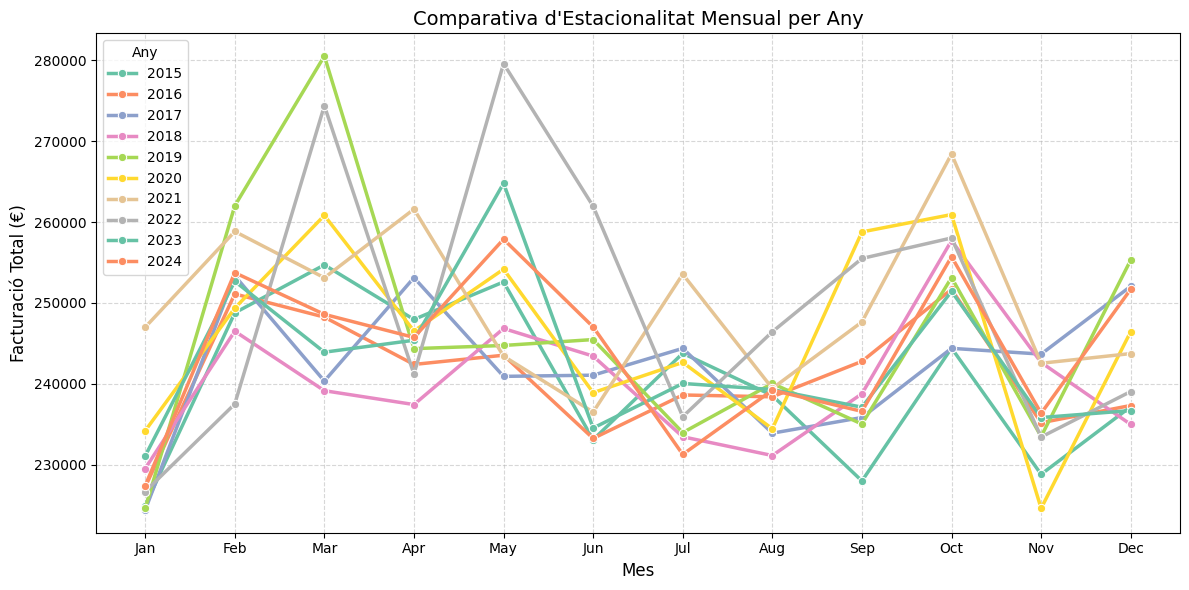

In [211]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=vendes_temps,
    x='month_name',
    y='amount',
    hue='year',
    marker='o',
    palette='Set2',
    linewidth=2.5,
)

plt.title("Comparativa d'Estacionalitat Mensual per Any", fontsize=14)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Facturació Total (€)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Any')
plt.tight_layout()
plt.show()

RESULTADO:
>* **Evolución y comportamiento general:** El gráfico analiza la facturación mensual entre 2015 y 2024, mostrando fluctuaciones constantes dentro de un rango recurrente de 230.000 € a 280.000 € a lo largo de los años.
>* **Patrones de estacionalidad:** Se observan repuntes significativos hacia el último trimestre del año en la mayoría de ejercicios, destacando picos pronunciados en meses intermedios como marzo y mayo según el año registrado.
>* **Años con valores atípicos:** Los años 2019 y 2022 presentan los ingresos más elevados del histórico, superando los 275.000 € en sus meses punta, destacándose claramente por encima del promedio general habitual.
>* **Periodos de menor volumen:** El inicio de los años suele mostrar valles de facturación pronunciados, registrándose los mínimos históricos cerca de los 225.000 €, lo que evidencia una clara menor actividad inicial.

**Anomalías:**

>* En 2022 hay un comportamiento atípico con un pico de ingresos mas elevado que el habitual llegando a 280.000€ (parte central-izquierda).

>* En 2021 localizamos un pico en la segunda mitad del año que destaca por sobre del resto del ejercicio.

## »Activitat d'usuaris

>* Hi ha usuaris que han deixat de comprar recentment?

>* Passos orientatius:

#### >> 1.Identificar l'última compra per usuari.

In [212]:
ultima_compra_usuari = (
    df_transactions.groupby('user_id')['timestamp'].max().reset_index()
)

In [213]:
ultima_compra_usuari

,user_id,timestamp
0,1,2024-11-15 14:48:20
1,2,2024-04-20 06:41:27
2,3,2024-02-22 03:31:36
3,4,2024-12-29 11:47:48
4,5,2024-05-02 21:11:06
...,...,...
4995,4996,2023-06-22 13:59:16
4996,4997,2024-10-05 10:01:11
4997,4998,2024-12-09 19:48:11
4998,4999,2024-08-04 04:51:44


#### >>2.Calcular el temps des de l'última compra.

In [214]:
data_referencia = df_transactions['timestamp'].max()

Calcular el tiempo, en dias, des de la última compra para cada usuario

In [215]:
ultima_compra_usuari['dies_des_de_darrera_compra'] = (
    data_referencia - ultima_compra_usuari['timestamp']
).dt.days

Visualización del resultado

In [216]:
ultima_compra_usuari.head()

,user_id,timestamp,dies_des_de_darrera_compra
0,1,2024-11-15 14:48:20,46
1,2,2024-04-20 06:41:27,255
2,3,2024-02-22 03:31:36,313
3,4,2024-12-29 11:47:48,2
4,5,2024-05-02 21:11:06,243


#### >> 3.Visualitzación de la distrbución del tiempo desde la última compra.

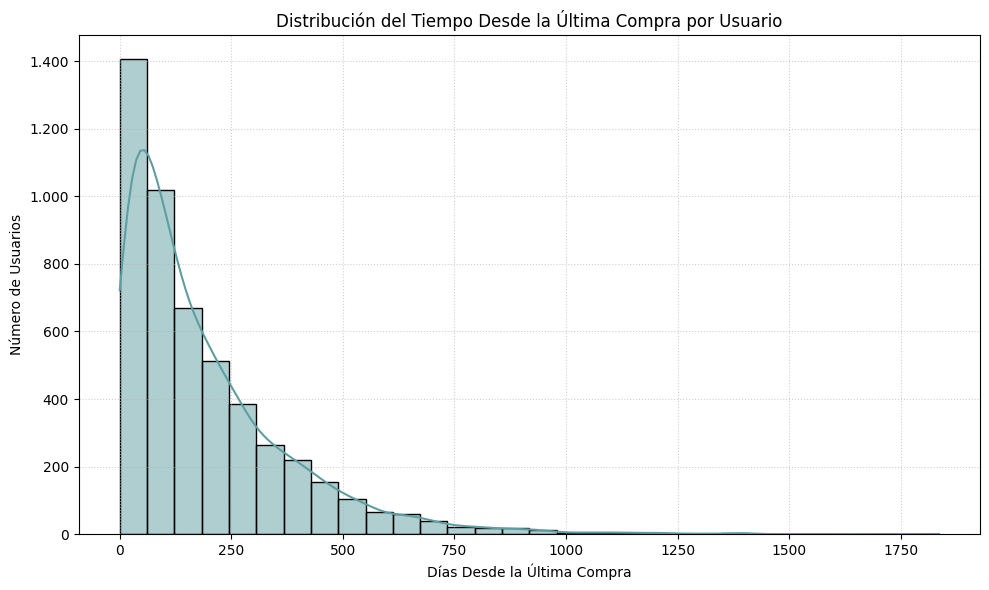

In [217]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=ultima_compra_usuari,
    x='dies_des_de_darrera_compra',
    kde=True,
    color='cadetblue',
    bins=30)

plt.title("Distribución del Tiempo Desde la Última Compra por Usuario")
plt.xlabel("Días Desde la Última Compra")
plt.ylabel("Número de Usuarios")
plt.grid(True, linestyle=':', alpha=0.6)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

plt.tight_layout()
plt.show()

**Resultado del gráfico:**
>* La mayoría de los clientes se concentran en la parte izquierda de la gráfica, lo que indica que han realizado una transacción recientemente.
>* Alta retención y actividad: La barra principal supera los 1.400 usuarios en el tramo de menor cantidad de días, demostrando una base de compradores activa y recurrente en la plataforma.
>* A medida que aumentan los días transcurridos sin comprar, la cantidad de usuarios decrece drásticamente, mostrando muy pocos clientes estancados o en riesgo de inactividad prolongada.



> » Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)

>* Passos orientatius:

>> 1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

>> 2. Construir una taula agregada utilitzant crosstab.

>> 3. Visualitzar amb un heatmap.

>* 👉 Per a cada pregunta:

> » Descriu breument els passos seguits.

> » Mostra la visualització final.

> » Interpreta què implica per al negoci.

Aseguramos que el campo sea datetime

In [218]:
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])

Extraemos el año y la hora

In [219]:
df_transactions['any'] = df_transactions['timestamp'].dt.year
df_transactions['hora'] = df_transactions['timestamp'].dt.hour

Creamos la función para marcar la franja horaria

In [220]:
def assignar_franja(hora):
    if 0 <= hora < 6:
        return '1. Matinada (00-06h)'
    elif hora < 12:
        return '2. Matí (06-12h)'
    elif hora < 18:
        return '3. Tarda (12-18h)'
    else:
        return '4. Nit (18-24h)'

df_transactions['franja_horaria'] = df_transactions['hora'].apply(assignar_franja)

Cambiar el if , parametros

Creamos Tabla agregada con crosstab (Volumne de facturación total)

In [221]:
taula_franges = pd.crosstab(
    index=df_transactions['any'],
    columns=df_transactions['franja_horaria'],
    values=df_transactions['amount'],
    aggfunc='sum'
).fillna(0)

Visualización con un Heatmap

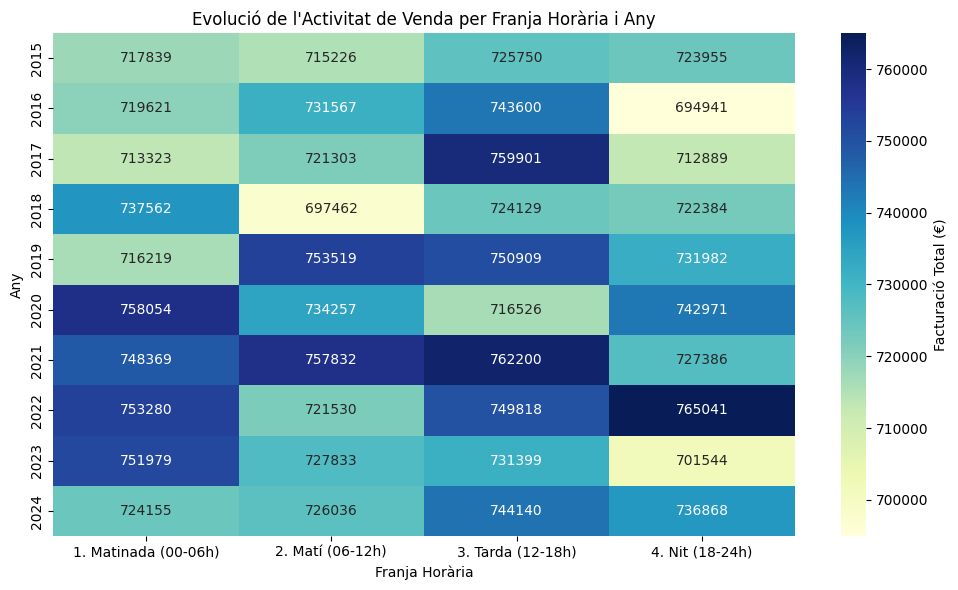

In [222]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    taula_franges,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Facturació Total (€)'}
)

plt.title("Evolució de l'Activitat de Venda per Franja Horària i Any")
plt.xlabel("Franja Horària")
plt.ylabel("Any")
plt.tight_layout()
plt.show()


**Resultado del gráfico:**
>* El mapa de calor refleja un incremento progresivo de las ventas con el paso de los años, pasando de tonos azules claros en 2015 a azules intensos predominantemente a partir de 2020.
>* Picos máximos de facturación: Los valores más elevados se concentran en periodos específicos como 2021 y 2022, destacando celdas con más de 760.000 € en azul marino que representan los máximos de facturación histórica.
>* **Periodos flojos:** Las celdas más diluidas y/o blancas señalan los momentos de menor actividad comercial, registrándose mínimos destacados por debajo de los 700.000 € en años puntuales como 2016, 2018 y el tramo final de 2023.


# **Nivell 2 – Anàlisi relacional i patrons avançats**

## Exercici 1: Anàlisi de productes i captació d'usuaris

#### 1-2.Combinació i definició

>>* Combina les taules necessàries.

>>* Defineix un criteri de nou usuari si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.

1.Preparación de datos y union de tablas.

In [223]:
df_trans = df_transactions.copy()
df_trans['timestamp'] = pd.to_datetime(df_trans['timestamp'])

#### 3.Agrega la informació per producte i calcula les mètriques següents:

>>* Ingressos totals.
>>* Variabilitat dels ingressos.
>>* Nombre de nous usuaris.
>>* Percentatge de nous usuaris sobre el total de compradors del producte.

Identificamos la fecha de la primera compra de cada usuario

In [224]:
primera_compra = df_trans.groupby('user_id')['timestamp'].transform('min')

In [225]:
df_trans['es_nou_usuari'] = df_trans['timestamp'] == primera_compra

Preparamos los datos de product_id

In [226]:
df_products = df_trans.assign(product_id=df_trans['product_ids'].str.split(',')).explode('product_id')
df_products['product_id'] = df_products['product_id'].str.strip()

Agregación de métricas por producto

In [227]:
product_metrics = df_products.groupby('product_id').agg(
    ingressos_totals=('amount', 'sum'),
    variabilitat_ingressos=('amount', 'std'),
    total_compradors=('user_id', 'nunique'),
    nous_usuaris=('user_id', lambda x: df_products.loc[x.index][df_products.loc[x.index]['es_nou_usuari']]['user_id'].nunique())
).reset_index()

Calculamos el porcentaje de nuevos usuarios.

In [228]:
product_metrics['pct_nous_usuaris'] = (product_metrics['nous_usuaris'] / product_metrics['total_compradors']) * 100
product_metrics['variabilitat_ingressos'] = product_metrics['variabilitat_ingressos'].fillna(0)

Creamos la tipología analítica de productos

In [229]:
mediana_ingressos = product_metrics['ingressos_totals'].median()
mediana_captacio = product_metrics['nous_usuaris'].median()

In [230]:
def classificar_producte(row):
    if row['ingressos_totals'] >= mediana_ingressos and row['nous_usuaris'] >= mediana_captacio:
        return 'Captador'
    elif row['ingressos_totals'] >= mediana_ingressos and row['nous_usuaris'] < mediana_captacio:
        return 'Recurrent'
    elif row['ingressos_totals'] < mediana_ingressos and row['nous_usuaris'] >= mediana_captacio:
        return 'Emergent'
    else:
        return 'Estancat'

product_metrics['tipologia'] = product_metrics.apply(classificar_producte, axis=1)

#### 4.Creació d'una tipologia analítica de productes a partir de les mètriques calculades, per exemple:

>>* Captador: alta captació de nous usuaris.
>>* Recurrent: ingressos elevats però baixa captació.
>>* Emergent: baixa facturació però bona captació.
>>* Estancat: baixos ingressos i baixa captaci

#### 5.Construeix una visualització que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:

>>* Eix X → ingressos totals per producte.
>>* Eix Y → nombre de nous usuaris.
>>* Mida del punt → variabilitat dels ingressos.
>>* Color del punt → tipologia analítica del producte.

Visualización

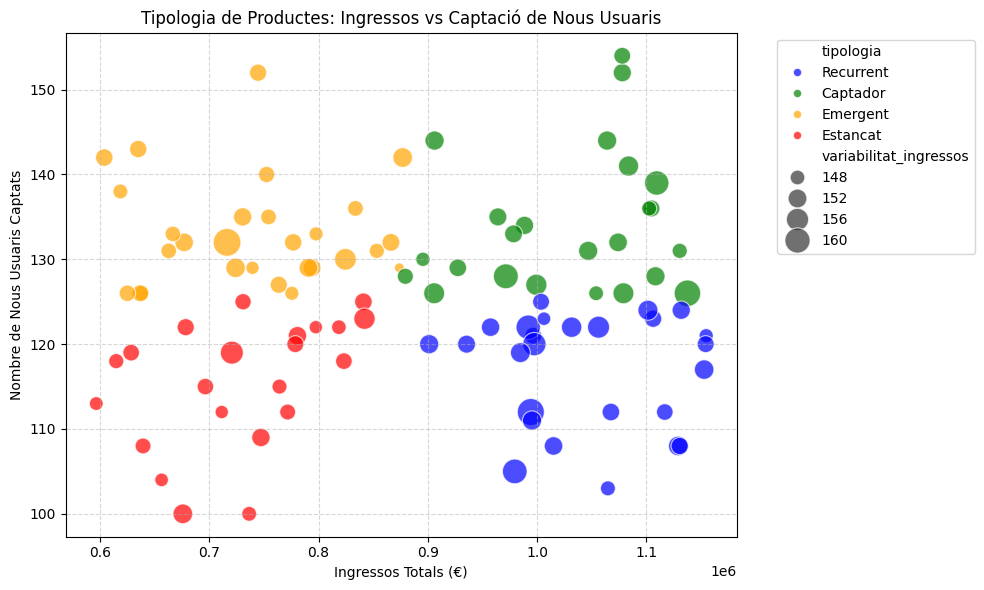

In [231]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=product_metrics,
    x='ingressos_totals',
    y='nous_usuaris',
    size='variabilitat_ingressos',
    hue='tipologia',
    sizes=(50, 400),
    palette={'Captador': 'green', 'Recurrent': 'blue', 'Emergent': 'orange', 'Estancat': 'red'},
    alpha=0.7
)

plt.title('Tipologia de Productes: Ingressos vs Captació de Nous Usuaris')
plt.xlabel('Ingressos Totals (€)')
plt.ylabel('Nombre de Nous Usuaris Captats')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Resultado del gráfico:**
>* **Segmentación clara:** El gráfico dispersa los productos en cuatro tipos bien diferenciados según la captación de usuarios y su recurrencia, identificando patrones de comportamiento únicos para cada grupo analizado.
>* **Productos de alta captación (Captador/Emergente):** Los clústeres superior amarillo y verde destacan por atraer el mayor volumen de nuevos usuarios (entre 125 y 144), posicionándose como los motores principales para la adquisición de clientes.
>* **Productos de baja captación (Estancat/Recurrent):** Los grupos inferior rojo y azul se sitúan por debajo de 125 usuarios captados, mostrando un menor rendimiento en captación pero actuando como base consolidada o productos a la baja.
>* **Dimensión de la variabilidad de ingresos:** El tamaño de cada burbuja refleja el volumen facturado, permitiendo identificar fácilmente qué productos presentan ingresos estables y cuáles sufren oscilaciones o devaluaciones importantes.